# From a PDB File to a Protein-Protein Interaction Graph — Barnase/Barstar (1BRS)

This notebook is a from-scratch, line-by-line walkthrough of the pipeline in `pipeline.py`,
run against a **real** crystal structure instead of a toy example: **1BRS**, the
barnase–barstar complex (the classic protein-protein interaction benchmark).

We will go, in order:

1. What a `.pdb` file actually contains, as raw text.
2. How BioPython turns that text into Python objects (`Structure > Model > Chain > Residue > Atom`).
3. Pulling one chain's residues out (identity + 3D coordinate).
4. Encoding amino-acid identity as a feature vector (one-hot).
5. Computing the distance matrix between two chains — the geometric core of everything that follows.
6. Turning distances into a 0/1 **contact matrix**.
7. Turning contacts into per-residue **interface labels** (this is the thing we eventually want a model to predict).
8. Building the **intra-chain structural graph** a GNN would actually see at inference time.
9. (Bonus) A stricter, literature-standard interface definition using all atoms, not just the backbone `CA`.
10. Packaging everything into a `torch_geometric.data.Data` graph object.

No step is hidden behind a library call you can't inspect — every matrix here is built with plain
`numpy` broadcasting so you can see exactly what "distance matrix" and "contact matrix" mean in code.


## 0. Setup

We need:
- `numpy` — all the actual math (distances, thresholding).
- `matplotlib` — visualizing matrices as heatmaps, which makes the shapes much easier to reason about than printed arrays.
- `Bio.PDB` (BioPython) — parses the PDB text format into a navigable Python object tree.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa
import warnings
warnings.filterwarnings("ignore")  # BioPython warns about minor PDB format quirks; harmless for our purposes

PDB_PATH = "1BRS.pdb"


## 1. What actually *is* a PDB file?

A `.pdb` file is plain ASCII text. It is **not** CSV, **not** whitespace-delimited — it's a
fixed-column format from the 1970s, where every field lives at an exact character position
regardless of how it looks. Before touching any parsing library, let's read it with our own eyes.

The file is organized into **records**, each identified by the keyword in columns 1–6:

| Record | Meaning |
|---|---|
| `HEADER` | one-line classification + PDB ID + deposition date |
| `TITLE` | free-text description of the structure |
| `COMPND` | which molecule each chain is (crucial when there are multiple chains!) |
| `SOURCE` | the organism the protein came from |
| `SEQRES` | the *intended* amino-acid sequence of each chain, from the gene/construct |
| `ATOM` | one line per resolved atom of a standard amino acid — the actual 3D coordinates |
| `HETATM` | one line per atom that ISN'T a standard amino acid (waters, ions, ligands, ...) |
| `TER` | marks the end of a chain's chain of atoms |
| `END` | end of file |

Let's look at the real header of 1BRS.


In [2]:
with open(PDB_PATH) as f:
    lines = f.readlines()

print(f"Total lines in file: {len(lines)}\n")
for line in lines:
    if line.startswith(("HEADER", "TITLE", "COMPND")):
        print(line.rstrip())


Total lines in file: 5765

HEADER    ENDONUCLEASE                            11-MAR-94   1BRS
TITLE     PROTEIN-PROTEIN RECOGNITION: CRYSTAL STRUCTURAL ANALYSIS OF A BARNASE-
TITLE    2 BARSTAR COMPLEX AT 2.0-A RESOLUTION
COMPND    MOL_ID: 1;
COMPND   2 MOLECULE: BARNASE;
COMPND   3 CHAIN: A, B, C;
COMPND   4 EC: 3.1.27.-;
COMPND   5 ENGINEERED: YES;
COMPND   6 MOL_ID: 2;
COMPND   7 MOLECULE: BARSTAR;
COMPND   8 CHAIN: D, E, F;
COMPND   9 ENGINEERED: YES


Two things to notice immediately:

- **`COMPND`** tells us this file has **two different molecules**: `BARNASE` on chains `A, B, C`
  and `BARSTAR` on chains `D, E, F`. That's 6 chains total, but only *two* distinct proteins —
  the crystal simply contains **3 copies of the same complex** packed together (common in
  crystallography; more on this below).
- The `TITLE` literally tells us this is a protein-protein recognition study — this structure
  was solved specifically to look at this interface.


In [3]:
print("First 5 SEQRES lines for chain A (barnase's intended sequence):\n")
for line in lines:
    if line.startswith("SEQRES") and line[11] == "A":
        print(line.rstrip())


First 5 SEQRES lines for chain A (barnase's intended sequence):

SEQRES   1 A  110  ALA GLN VAL ILE ASN THR PHE ASP GLY VAL ALA ASP TYR
SEQRES   2 A  110  LEU GLN THR TYR HIS LYS LEU PRO ASP ASN TYR ILE THR
SEQRES   3 A  110  LYS SER GLU ALA GLN ALA LEU GLY TRP VAL ALA SER LYS
SEQRES   4 A  110  GLY ASN LEU ALA ASP VAL ALA PRO GLY LYS SER ILE GLY
SEQRES   5 A  110  GLY ASP ILE PHE SER ASN ARG GLU GLY LYS LEU PRO GLY
SEQRES   6 A  110  LYS SER GLY ARG THR TRP ARG GLU ALA ASP ILE ASN TYR
SEQRES   7 A  110  THR SER GLY PHE ARG ASN SER ASP ARG ILE LEU TYR SER
SEQRES   8 A  110  SER ASP TRP LEU ILE TYR LYS THR THR ASP HIS TYR GLN
SEQRES   9 A  110  THR PHE THR LYS ILE ARG


`SEQRES` is the sequence **as designed/expressed** — it's a fact about the molecule, not
about what the crystal experiment actually resolved. Keep this number in your head
(chain A = 110 residues); we'll come back to it, because the `ATOM` records below won't
necessarily match it.


### Reading a single `ATOM` line by eye

Here is the fixed-column layout for an `ATOM` record:

| Columns (1-indexed) | Field | Meaning |
|---|---|---|
| 1–6 | Record name | `ATOM` |
| 7–11 | Atom serial number | unique atom index in the file |
| 13–16 | Atom name | e.g. `CA` = alpha carbon, `N`, `C`, `O`, side-chain atoms `CB`, `CG`, ... |
| 18–20 | Residue name | 3-letter amino acid code, e.g. `ALA` |
| 22 | **Chain identifier** | e.g. `A` |
| 23–26 | Residue sequence number | position of this residue along the chain |
| 31–38, 39–46, 47–54 | x, y, z | 3D coordinates in Angstroms (Å) |

This is why the format survives residue names running up against chain IDs with no visible space —
the parser never "splits on whitespace", it slices by column position.


In [4]:
atom_lines = [l for l in lines if l.startswith("ATOM")]
example = atom_lines[0]

print("Raw line:")
print(repr(example))
print()
print("Manually sliced by column position (this is exactly what a PDB parser does):")
print("  record name  (cols 1-6)  :", example[0:6].strip())
print("  atom serial  (cols 7-11) :", example[6:11].strip())
print("  atom name    (cols 13-16):", example[12:16].strip())
print("  residue name (cols 18-20):", example[17:20].strip())
print("  chain id     (col 22)    :", example[21])
print("  residue seq# (cols 23-26):", example[22:26].strip())
print("  x (cols 31-38)           :", example[30:38].strip())
print("  y (cols 39-46)           :", example[38:46].strip())
print("  z (cols 47-54)           :", example[46:54].strip())


Raw line:
'ATOM      1  N   VAL A   3      16.783  48.812  26.447  1.00 30.15           N  \n'

Manually sliced by column position (this is exactly what a PDB parser does):
  record name  (cols 1-6)  : ATOM
  atom serial  (cols 7-11) : 1
  atom name    (cols 13-16): N
  residue name (cols 18-20): VAL
  chain id     (col 22)    : A
  residue seq# (cols 23-26): 3
  x (cols 31-38)           : 16.783
  y (cols 39-46)           : 48.812
  z (cols 47-54)           : 26.447


That's the entire "trick" of PDB parsing. Everything BioPython does below is this same
column-slicing logic, wrapped in an object model so you don't do it by hand for 4,000+ atom lines.


## 2. From text to objects: the BioPython `Structure` hierarchy

BioPython's `Bio.PDB` module parses the whole file into a nested object tree, called **SMCRA**:

```
Structure
 └── Model            (crystal structures normally have exactly 1; NMR structures have many)
      └── Chain        (one per chain ID, e.g. 'A')
           └── Residue (one per ATOM/HETATM group sharing a residue number)
                └── Atom (one per ATOM/HETATM line — has .coord, a numpy xyz array)
```

You navigate it exactly like nested dictionaries/lists: `structure[model_id][chain_id]`, then
iterate residues, then index atoms by name (`residue["CA"]`).


In [5]:
def parse_structure(path, structure_id="X"):
    '''Step 1: load a .pdb file into a Bio.PDB Structure object.'''
    parser = PDBParser(QUIET=True)
    return parser.get_structure(structure_id, path)


structure = parse_structure(PDB_PATH, structure_id="1BRS")
model = structure[0]

print(f"Structure has {len(structure)} model(s).")
print(f"Model 0 has {len(model)} chain(s): {[c.id for c in model]}\n")

for chain in model:
    n_residues = len(chain)  # includes water molecules etc, see below
    print(f"  chain {chain.id}: {n_residues} residue-like groups (incl. waters/hetero groups)")


Structure has 1 model(s).
Model 0 has 6 chain(s): ['A', 'B', 'C', 'D', 'E', 'F']

  chain A: 253 residue-like groups (incl. waters/hetero groups)
  chain B: 247 residue-like groups (incl. waters/hetero groups)
  chain C: 158 residue-like groups (incl. waters/hetero groups)
  chain D: 164 residue-like groups (incl. waters/hetero groups)
  chain E: 150 residue-like groups (incl. waters/hetero groups)
  chain F: 129 residue-like groups (incl. waters/hetero groups)


## Why does this asymmetric unit have 6 chains for a 2-protein complex?

X-ray crystallography solves the structure of whatever repeating unit happened to pack into the
crystal — the **asymmetric unit** — which frequently contains more than one physical copy of the
biological complex, purely as an artifact of how the crystal lattice is built. `COMPND` already
told us the mapping: barnase = `A, B, C`, barstar = `D, E, F`. The real biological question is
*which barnase chain actually touches which barstar chain* — that is not guaranteed to be
`A↔D, B↔E, C↔F` just because of alphabetical order; we should **verify it geometrically**, which
we're about to be able to do once we've built the distance-matrix function. Keep this question
open for a few cells.


## 3. Pulling one chain's residues out

For each chain we want a clean list of *only the real amino acids* (drop water `HOH`, ions,
ligands, anything non-standard), each with:
- its position along the chain (`resseq`),
- its identity (`resname`, e.g. `ALA`),
- and a single representative 3D coordinate.

We use the **alpha carbon (`CA`)** atom as that representative coordinate. Every standard amino
acid has exactly one CA — it sits on the protein backbone — so using CA-only positions is the
standard cheap way to represent "where is this residue" without tracking every side-chain atom.

`is_aa(res, standard=True)` is what filters out water and other hetero groups; a residue is also
skipped if, for some reason, its CA didn't get resolved in the crystal (rare, but real data is
messier than toy data — see the residue-count check right after).


In [6]:
AA3 = ["ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS","ILE",
       "LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"]
AA_INDEX = {aa: i for i, aa in enumerate(AA3)}


def get_chain_residues(structure, chain_id, model_idx=0):
    '''
    Step 2: pull real amino-acid residues (skip waters/ligands/hetero groups)
    out of one chain. Returns a list of dicts, one per residue, each holding
    the residue's CA coordinate and its amino-acid one-hot index.
    Residues without a CA atom (rare, e.g. disordered) are skipped.
    '''
    chain = structure[model_idx][chain_id]
    residues = []
    for res in chain:
        if not is_aa(res, standard=True):
            continue  # drops HOH, ligands, ions, non-standard residues
        if "CA" not in res:
            continue
        residues.append({
            "resseq": res.id[1],
            "resname": res.resname,
            "aa_index": AA_INDEX.get(res.resname, 20),  # 20 = "unknown"
            "coord": res["CA"].coord,  # numpy array, shape (3,)
        })
    return residues


# Barnase's first copy is chain A, barstar's first copy is chain D
res_a = get_chain_residues(structure, "A")
res_d = get_chain_residues(structure, "D")

print(f"Chain A (barnase) resolved residues: {len(res_a)}   (SEQRES said 110)")
print(f"Chain D (barstar) resolved residues: {len(res_d)}   (SEQRES said 89)")


Chain A (barnase) resolved residues: 108   (SEQRES said 110)
Chain D (barstar) resolved residues: 87   (SEQRES said 89)


Notice the mismatch with `SEQRES`. This is normal and important: `SEQRES` is the designed
sequence, but a handful of residues (often flexible chain termini) don't show up cleanly enough
in the electron density to be resolved as atoms — so they're simply absent from the `ATOM`
records. **Any real pipeline has to tolerate this** — a toy hand-built PDB never shows you this,
but 1BRS does.


## 4. Encoding amino acid identity: one-hot vectors

A GNN (or any neural net) needs numbers, not strings like `"ALA"`. The simplest, most standard
encoding for a categorical identity like "which of the 20 amino acids is this" is **one-hot**:
a vector of length 21 (20 standard amino acids + 1 "unknown" bucket) that is all zeros except a
single `1` at the index of this residue's type.

We deliberately do *not* encode amino acid identity as a single integer (e.g. `ALA=0, ARG=1, ...`)
because that would imply a false ordering/distance between amino acids that don't have one —
one-hot keeps every amino acid equally "far" from every other a priori, and lets the model learn
any structure in the relationships itself.


In [7]:
def one_hot_features(residues):
    '''Node feature matrix: (N, 21) one-hot amino-acid identity.'''
    x = np.zeros((len(residues), 21), dtype=np.float32)
    for i, r in enumerate(residues):
        x[i, r["aa_index"]] = 1.0
    return x


x_a = one_hot_features(res_a)
print("Chain A feature matrix shape:", x_a.shape, " (N_residues x 21)")

# sanity check: does row 0's one-hot index match its actual resname?
i = 0
recovered_index = x_a[i].argmax()
print(f"Residue 0 is {res_a[i]['resname']!r}; one-hot argmax index = {recovered_index}; "
      f"AA3[{recovered_index}] = {AA3[recovered_index]!r}")


Chain A feature matrix shape: (108, 21)  (N_residues x 21)
Residue 0 is 'VAL'; one-hot argmax index = 19; AA3[19] = 'VAL'


## 5. The distance matrix — the geometric heart of the pipeline

Everything about "contacts" and "interfaces" downstream reduces to one question: **how far apart
in 3D space is every residue of chain A from every residue of chain B?**

Given `NA` residues in chain A and `NB` residues in chain B, we want an `NA x NB` matrix `D` where
`D[i, j]` = the Euclidean distance between residue `i`'s CA and residue `j`'s CA.

We compute this with **numpy broadcasting** — no hidden library call, this literally *is* the
pairwise distance computation:

```
coords_a: shape (NA, 3)
coords_b: shape (NB, 3)

coords_a[:, None, :]  -> shape (NA, 1, 3)
coords_b[None, :, :]  -> shape (1, NB, 3)

difference            -> shape (NA, NB, 3)   (broadcast subtracts every A row from every B row)
norm over last axis   -> shape (NA, NB)      (Euclidean distance, collapsing the (dx,dy,dz) axis)
```

Let's see the shapes with a tiny example before doing it on the real chains.


In [8]:
# Tiny worked example: 3 points in chain A, 2 points in chain B, in 3D
toy_a = np.array([[0,0,0], [1,0,0], [2,0,0]], dtype=float)   # shape (3, 3)
toy_b = np.array([[0,0,1], [5,0,0]], dtype=float)             # shape (2, 3)

print("coords_a shape:", toy_a.shape)
print("coords_b shape:", toy_b.shape)

diff = toy_a[:, None, :] - toy_b[None, :, :]
print("broadcast diff shape:", diff.shape, " <- (NA, NB, 3)")

toy_dist = np.linalg.norm(diff, axis=-1)
print("distance matrix shape:", toy_dist.shape, " <- (NA, NB)")
print(toy_dist)
print("\nCheck by hand: point A0=(0,0,0) to B0=(0,0,1) should be 1.0 ->", toy_dist[0,0])
print("Check by hand: point A2=(2,0,0) to B1=(5,0,0) should be 3.0 ->", toy_dist[2,1])


coords_a shape: (3, 3)
coords_b shape: (2, 3)
broadcast diff shape: (3, 2, 3)  <- (NA, NB, 3)
distance matrix shape: (3, 2)  <- (NA, NB)
[[1.         5.        ]
 [1.41421356 4.        ]
 [2.23606798 3.        ]]

Check by hand: point A0=(0,0,0) to B0=(0,0,1) should be 1.0 -> 1.0
Check by hand: point A2=(2,0,0) to B1=(5,0,0) should be 3.0 -> 3.0


In [9]:
def compute_distance_matrix(residues_a, residues_b):
    '''
    Step 3: the actual N_A x N_B distance matrix, done ourselves with numpy
    broadcasting (no hidden library magic) using CA-CA distance.
    '''
    coords_a = np.array([r["coord"] for r in residues_a])  # (NA, 3)
    coords_b = np.array([r["coord"] for r in residues_b])  # (NB, 3)
    diff = coords_a[:, None, :] - coords_b[None, :, :]
    dist_matrix = np.linalg.norm(diff, axis=-1)
    return dist_matrix


dist_ad = compute_distance_matrix(res_a, res_d)
print("Chain A x Chain D distance matrix shape:", dist_ad.shape)
print("Closest CA-CA pair across the interface: %.2f Angstroms" % dist_ad.min())
print("Farthest CA-CA pair (opposite corners of the two proteins): %.2f Angstroms" % dist_ad.max())


Chain A x Chain D distance matrix shape: (108, 87)
Closest CA-CA pair across the interface: 4.83 Angstroms
Farthest CA-CA pair (opposite corners of the two proteins): 52.25 Angstroms


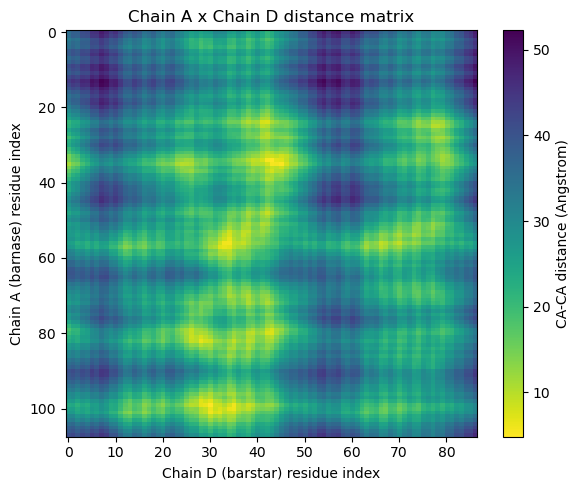

In [10]:
plt.figure(figsize=(6, 5))
plt.imshow(dist_ad, cmap="viridis_r", aspect="auto")
plt.colorbar(label="CA-CA distance (Angstrom)")
plt.xlabel("Chain D (barstar) residue index")
plt.ylabel("Chain A (barnase) residue index")
plt.title("Chain A x Chain D distance matrix")
plt.tight_layout()
plt.show()


Dark bands (low distance) show *where along each chain's sequence* the two proteins come
close together in 3D — this is the interface, and it will only be a small patch of each sequence,
not the whole chain. That's the entire point of the next steps: turning "close in space" into
an explicit label.


## 6. From distances to contacts: thresholding

A **contact matrix** is just the distance matrix thresholded into 0/1: "are these two residues
close enough to plausibly be touching?"

```
contact[i,j] = 1  if dist[i,j] <= threshold  else 0
```

The threshold you pick matters a lot, and depends on *what* you measured the distance between:

- **CA–CA distance, threshold ≈ 8 Å**: loose/coarse. Because CAs sit on the backbone, not on the
  side chains that actually touch the other protein, you need a generous radius to catch real
  contacts. This is good enough for building a general *structural graph* (e.g. "which residues
  are near each other along the fold"), but too loose to claim two residues are truly touching.
- **All-atom (heavy-atom) minimum distance, threshold ≈ 4.5–5 Å**: this is the literature-standard
  definition of a *true* interface contact — it looks at every non-hydrogen atom of residue *i*
  against every non-hydrogen atom of residue *j*, and calls it a contact if the closest pair of
  atoms is within the cutoff. We'll build this stricter version too, in the bonus section, now
  that we have a real all-atom PDB file (the CA-only toy example couldn't show this distinction).

For now, let's use the same CA/8 Å convention as `pipeline.py`.


Number of CA-CA contacts (<= 8A): 36
Out of a possible 9396 pairs (VAL... 108 x 87)


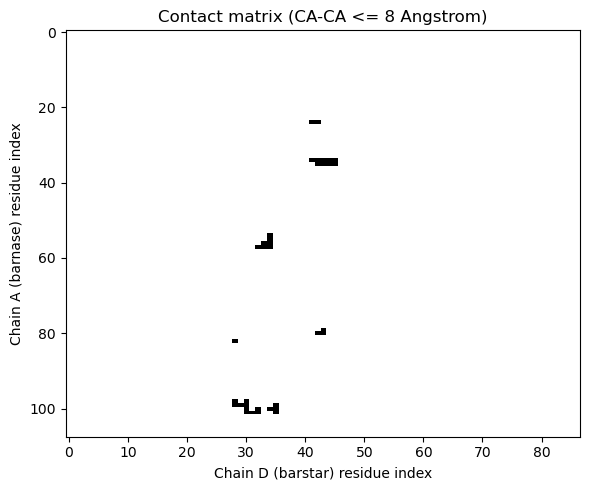

In [11]:
def compute_contact_matrix(dist_matrix, threshold=8.0):
    '''Step 4: threshold distances into a 0/1 contact matrix.'''
    return (dist_matrix <= threshold).astype(int)


contact_ad = compute_contact_matrix(dist_ad, threshold=8.0)
print("Number of CA-CA contacts (<= 8A):", contact_ad.sum())
print("Out of a possible", contact_ad.size, f"pairs ({res_a[0]['resname']}... {len(res_a)} x {len(res_d)})")

plt.figure(figsize=(6, 5))
plt.imshow(contact_ad, cmap="Greys", aspect="auto")
plt.xlabel("Chain D (barstar) residue index")
plt.ylabel("Chain A (barnase) residue index")
plt.title("Contact matrix (CA-CA <= 8 Angstrom)")
plt.tight_layout()
plt.show()


### Verifying the "3 copies" claim computationally

Earlier, `COMPND` told us barnase is chains A/B/C and barstar is D/E/F, and we assumed the
biologically real pairs are A↔D, B↔E, C↔F. Now that we have `compute_distance_matrix`, we don't
have to take that on faith — we can check every barnase chain against every barstar chain and see
which pairs actually have contacts.


In [12]:
barnase_chains = ["A", "B", "C"]
barstar_chains = ["D", "E", "F"]

print(f"{'barnase':>8} {'barstar':>8} {'min CA-CA dist (A)':>20} {'# contacts <=8A':>18}")
for bn in barnase_chains:
    res_bn = get_chain_residues(structure, bn)
    for bs in barstar_chains:
        res_bs = get_chain_residues(structure, bs)
        d = compute_distance_matrix(res_bn, res_bs)
        c = compute_contact_matrix(d, threshold=8.0)
        print(f"{bn:>8} {bs:>8} {d.min():>20.2f} {int(c.sum()):>18}")


 barnase  barstar   min CA-CA dist (A)    # contacts <=8A
       A        D                 4.83                 36
       A        E                22.21                  0
       A        F                23.00                  0
       B        D                23.12                  0
       B        E                 4.82                 36
       B        F                32.63                  0
       C        D                18.60                  0
       C        E                12.82                  0
       C        F                 4.94                 35


The result confirms it cleanly: only `A-D`, `B-E`, `C-F` have any contacts at all (tens of
Å of empty space separates every other combination) — three essentially independent copies of the
same barnase-barstar complex, sitting in the same crystal. This is exactly the kind of thing you
must check yourself on a new structure rather than assume from chain-letter order.


## 7. Interface labels: the thing we actually want to predict

This is the payoff of everything above. We define: **a residue is an "interface residue" if it
has at least one contact to any residue on the partner chain.**

In matrix terms, that's just an OR-reduction along each axis of the contact matrix:
- for chain A, OR across each **row** (does residue *i* touch *anything* in chain B?)
- for chain B, OR across each **column** (does residue *j* touch *anything* in chain A?)

This turns the 2D contact matrix into two 1D binary label vectors — exactly the target labels a
"protein-protein binding site prediction" model is trained to reproduce, given *only* the
structure of one chain (never seeing its partner).


In [13]:
def compute_interface_labels(contact_matrix):
    '''
    Step 5: a residue is an "interface residue" if it has >=1 contact
    to ANY residue on the other chain. Row-OR for chain A, column-OR for chain B.
    '''
    labels_a = (contact_matrix.sum(axis=1) > 0).astype(int)  # (NA,)
    labels_b = (contact_matrix.sum(axis=0) > 0).astype(int)  # (NB,)
    return labels_a, labels_b


labels_a, labels_d = compute_interface_labels(contact_ad)

print(f"Chain A (barnase, {len(res_a)} residues): "
      f"{labels_a.sum()} interface residues, {len(labels_a) - labels_a.sum()} non-interface")
print(f"Chain D (barstar, {len(res_d)} residues): "
      f"{labels_d.sum()} interface residues, {len(labels_d) - labels_d.sum()} non-interface")

interface_residues_a = [(r["resseq"], r["resname"]) for r, lab in zip(res_a, labels_a) if lab == 1]
print("\nChain A interface residues (resseq, resname):")
print(interface_residues_a)


Chain A (barnase, 108 residues): 14 interface residues, 94 non-interface
Chain D (barstar, 87 residues): 13 interface residues, 74 non-interface

Chain A interface residues (resseq, resname):
[(27, 'LYS'), (37, 'ALA'), (38, 'SER'), (57, 'SER'), (58, 'ASN'), (59, 'ARG'), (60, 'GLU'), (82, 'PHE'), (83, 'ARG'), (85, 'SER'), (101, 'ASP'), (102, 'HIS'), (103, 'TYR'), (104, 'GLN')]


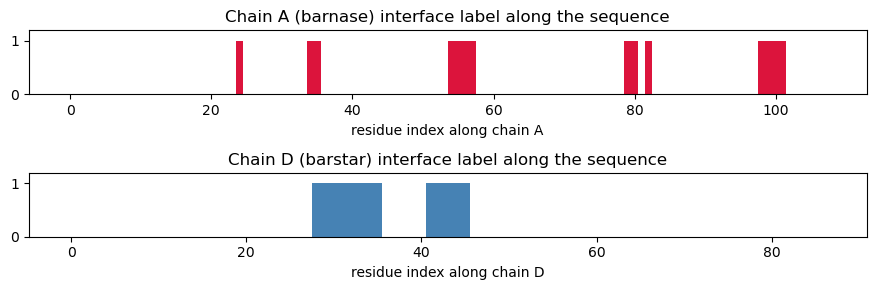

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 3), sharex=False)

axes[0].bar(range(len(labels_a)), labels_a, color="crimson", width=1.0)
axes[0].set_title("Chain A (barnase) interface label along the sequence")
axes[0].set_ylim(0, 1.2)
axes[0].set_xlabel("residue index along chain A")

axes[1].bar(range(len(labels_d)), labels_d, color="steelblue", width=1.0)
axes[1].set_title("Chain D (barstar) interface label along the sequence")
axes[1].set_ylim(0, 1.2)
axes[1].set_xlabel("residue index along chain D")

plt.tight_layout()
plt.show()


Notice the interface residues aren't scattered randomly along the sequence — they cluster
into one or two contiguous-ish patches. That's expected: a folded protein brings sequence-distant
residues together in 3D to form one physical binding surface, which is exactly why we need the
*3D structure* (not just the raw sequence) to find it.


## 8. Bonus: how loose is "CA-only, 8 Å" really?

Let's build the stricter, literature-standard definition and compare: **minimum heavy-atom
(non-hydrogen, all-atom) distance between two residues, threshold 4.5 Å.** Unlike the toy example
in `pipeline.py` (which only ever had CA coordinates), our real 1BRS structure has every atom, so
we can actually do this comparison now.

For each residue we collect *all* its non-hydrogen atom coordinates (not just CA), then for a pair
of residues (i, j) we take the **minimum** distance over every atom-pair combination — that's the
distance at which the two side chains/backbones actually get closest to touching.


In [15]:
def get_chain_heavy_atoms(structure, chain_id, model_idx=0):
    '''Like get_chain_residues, but keeps ALL non-hydrogen atom coordinates per residue.'''
    chain = structure[model_idx][chain_id]
    residues = []
    for res in chain:
        if not is_aa(res, standard=True):
            continue
        atoms = np.array([a.coord for a in res if a.element != "H"])
        if len(atoms) == 0:
            continue
        residues.append({"resseq": res.id[1], "resname": res.resname, "atoms": atoms})
    return residues


def compute_heavy_atom_contact_matrix(residues_a, residues_b, threshold=4.5):
    '''NA x NB contact matrix using minimum all-atom distance per residue pair.'''
    na, nb = len(residues_a), len(residues_b)
    contact = np.zeros((na, nb), dtype=int)
    for i, ra in enumerate(residues_a):
        for j, rb in enumerate(residues_b):
            diff = ra["atoms"][:, None, :] - rb["atoms"][None, :, :]
            min_dist = np.linalg.norm(diff, axis=-1).min()
            contact[i, j] = int(min_dist <= threshold)
    return contact


heavy_a = get_chain_heavy_atoms(structure, "A")
heavy_d = get_chain_heavy_atoms(structure, "D")

heavy_contact_ad = compute_heavy_atom_contact_matrix(heavy_a, heavy_d, threshold=4.5)
heavy_labels_a, heavy_labels_d = compute_interface_labels(heavy_contact_ad)

print("=== Comparison of interface definitions on chain A (barnase) ===")
print(f"CA-only,   8.0A cutoff -> {labels_a.sum()} interface residues out of {len(labels_a)}")
print(f"Heavy-atom,4.5A cutoff -> {heavy_labels_a.sum()} interface residues out of {len(heavy_labels_a)}")


=== Comparison of interface definitions on chain A (barnase) ===
CA-only,   8.0A cutoff -> 14 interface residues out of 108
Heavy-atom,4.5A cutoff -> 19 interface residues out of 108


Both definitions broadly agree on the *core* of the interface, but the heavy-atom/4.5Å
version is stricter and more precise — it won't flag a residue just because its backbone CA
happens to be within 8Å while its side chain actually points away from the partner. When you
build real interface-prediction datasets (e.g. for training a GNN), **the heavy-atom definition
is the one used in the literature** (e.g. in benchmarks like DBD5/PPI4DOCK); the CA/8Å version is
mainly useful for the *structural graph* (step 8 below), not for the labels themselves.


## 9. The intra-chain structural graph — what a GNN actually sees at inference time

Important subtlety: when you *use* a trained model to predict binding sites on a brand-new,
single protein, you don't get to see its partner — that's the whole point of *predicting* an
interface instead of just measuring one from a known complex. So the **input graph** fed to a GNN
must be built from **one chain's own structure only**: two residues get an edge if their CAs are
within a threshold of each other, regardless of the other chain. The interface label (from the
complex) is only used as the training *target*, never as an input feature.


In [16]:
def build_intra_chain_edges(residues, threshold=8.0):
    '''
    Structural graph WITHIN one chain: two residues get an edge if their
    CAs are within `threshold` Angstroms of each other (this is the graph
    a GNN would actually see at inference time -- it only needs ONE chain's
    own structure, not the partner's).
    Returns edge_index in PyG's [2, num_edges] COO format (both directions).
    '''
    coords = np.array([r["coord"] for r in residues])
    diff = coords[:, None, :] - coords[None, :, :]
    d = np.linalg.norm(diff, axis=-1)
    contact = (d <= threshold) & (d > 0)  # exclude self-loops
    src, dst = np.nonzero(contact)
    edge_index = np.stack([src, dst], axis=0)  # shape (2, num_edges)
    return edge_index


edge_index_a = build_intra_chain_edges(res_a, threshold=8.0)
print("Chain A intra-chain edge_index shape:", edge_index_a.shape, " (2, num_directed_edges)")
print("Average degree per residue:", edge_index_a.shape[1] / len(res_a))
print("\nFirst 10 edges (src_residue_idx, dst_residue_idx):")
print(edge_index_a[:, :10].T)


Chain A intra-chain edge_index shape: (2, 978)  (2, num_directed_edges)
Average degree per residue: 9.055555555555555

First 10 edges (src_residue_idx, dst_residue_idx):
[[ 0  1]
 [ 0  2]
 [ 0 20]
 [ 0 45]
 [ 1  0]
 [ 1  2]
 [ 1  3]
 [ 1  6]
 [ 1  7]
 [ 1 18]]


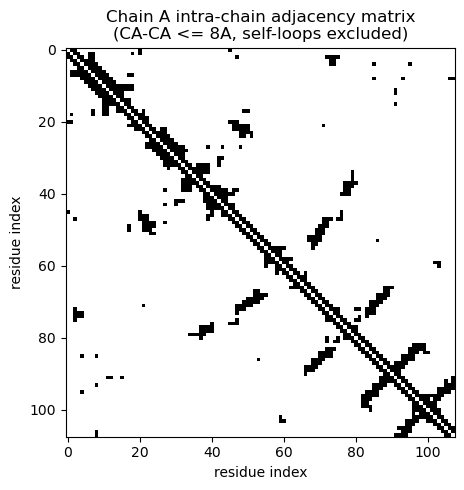

In [17]:
n = len(res_a)
adj = np.zeros((n, n), dtype=int)
adj[edge_index_a[0], edge_index_a[1]] = 1

plt.figure(figsize=(5, 5))
plt.imshow(adj, cmap="Greys")
plt.title("Chain A intra-chain adjacency matrix\n(CA-CA <= 8A, self-loops excluded)")
plt.xlabel("residue index")
plt.ylabel("residue index")
plt.tight_layout()
plt.show()


The thick diagonal band is expected: consecutive residues along the backbone are always
close together. The scattered off-diagonal dots are the more interesting long-range contacts —
places where the folded 3D structure brings sequence-distant residues close together. This is
*exactly* the extra information a graph neural network has access to that a plain "1D sequence
model" (like a language model reading amino acids left-to-right) does not.


## 10. Packaging it all into a graph object (`torch_geometric.data.Data`)

The very last step is bundling everything above into the object format a Graph Neural Network
library (PyTorch Geometric, "PyG") expects for one training example:

- `x`: `(N, 21)` node feature matrix — one-hot amino acid identity per residue.
- `edge_index`: `(2, E)` — the intra-chain structural graph, in COO (coordinate list) format.
- `y`: `(N,)` — the interface label per residue (0/1), the *target* the model is trained to predict.

This cell needs `torch` and `torch_geometric` installed, which are large, optional dependencies —
if they aren't available in this environment, the cell will tell you how to install them (e.g. in
Google Colab, which has them preinstalled) instead of crashing the rest of the notebook.


In [18]:
def build_pyg_data(residues, labels, edge_index):
    '''
    Step 6: package one chain into a torch_geometric.data.Data object.
    x         : (N, 21)  node features (one-hot amino acid)
    edge_index: (2, E)   intra-chain structural contacts
    y         : (N,)     interface label (0/1), derived from the COMPLEX
    '''
    import torch
    from torch_geometric.data import Data
    x = torch.tensor(one_hot_features(residues), dtype=torch.float)
    ei = torch.tensor(edge_index, dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.long)
    return Data(x=x, edge_index=ei, y=y)


try:
    data_a = build_pyg_data(res_a, labels_a, edge_index_a)
    print("Success! Chain A as a PyG graph:")
    print(data_a)
    print("\ndata.x.shape      :", tuple(data_a.x.shape))
    print("data.edge_index.shape:", tuple(data_a.edge_index.shape))
    print("data.y.shape      :", tuple(data_a.y.shape))
    print("Positive (interface) labels:", int(data_a.y.sum()), "/", data_a.y.shape[0])
except ImportError as e:
    print("torch / torch_geometric aren't installed in this environment:")
    print(" ", e)
    print()
    print("Everything up to this point (x, edge_index, labels) is plain numpy and already computed above.")
    print("To run this cell, install them, e.g.:")
    print("    pip install torch torch_geometric")
    print("(or run this notebook in Google Colab, which has torch preinstalled).")


torch / torch_geometric aren't installed in this environment:
  No module named 'torch'

Everything up to this point (x, edge_index, labels) is plain numpy and already computed above.
To run this cell, install them, e.g.:
    pip install torch torch_geometric
(or run this notebook in Google Colab, which has torch preinstalled).


## Recap

Starting from nothing but a raw `.pdb` text file, we built, by hand, every stage of a
protein-protein interface labeling pipeline:

1. **Parsed raw PDB text** into fixed-column fields, then into BioPython's `Structure` object tree.
2. **Extracted per-residue data** (identity + CA coordinate) for one chain at a time, handling the
   real-world messiness of unresolved residues.
3. **One-hot encoded** amino acid identity into a numeric feature matrix.
4. Computed the **NA × NB distance matrix** between two chains with numpy broadcasting.
5. Thresholded it into a **contact matrix**, and used contacts to *verify* (not assume) which
   chains in a multi-copy crystal are actually biological partners.
6. Reduced the contact matrix to **per-residue interface labels** — the actual prediction target.
7. Compared a loose **CA/8Å** contact definition against the stricter, literature-standard
   **heavy-atom/4.5Å** definition.
8. Built the **intra-chain structural graph** — the only input a real predictive model is allowed
   to see (never the partner's structure).
9. Packaged `x`, `edge_index`, `y` into a `torch_geometric.data.Data` object — one training example
   for a Graph Neural Network.

### Where this goes next
- Repeating this over **many** complexes (not just one) to build a training set — each complex
  becomes one or more `Data` graphs, split so that *entire complexes* (not individual residues)
  go into train/val/test, to avoid leaking information about a protein's own fold across splits.
- Choosing a GNN architecture (GCN, GAT, GraphSAGE, ...) that consumes `x` + `edge_index` and
  outputs a per-node probability, trained against `y` with a binary classification loss
  (interface residues are usually a small minority — class imbalance matters).
- Standard public datasets for this exact task if you want more than one structure to practice
  on: **DBD5** (Docking Benchmark 5), **MaSIF**, **PPI4DOCK**, all built with this same
  distance→contact→label logic.
